# Análisis por subgrupos: equidad del modelo

Un modelo con buen rendimiento global puede estar funcionando muy mal para ciertos grupos de pacientes. Si hay diferencias importantes eso tiene implicaciones directas sobre su equidad y su utilidad real.

En este notebook se evalúa el rendimiento del modelo (LightGBM) en cuatro dimensiones:

- **Grupos de edad**: <45, 45-65, 65-80, >80 años
- **Sexo**: femenino / masculino
- **Tipo de seguro médico**: Medicare, Medicaid, u otros
- **Diagnóstico principal**: sistema orgánico según clasificación ICD

Para cada subgrupo se calculan:
- **ROC-AUC**: capacidad discriminativa
- **Brier Score**: calibración de probabilidades, comparado con el baseline de predecir siempre la prevalencia del grupo

## 1. Imports y carga

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import joblib
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.models.train import load_data, split_data
from src.data.load import load_csv
from src.config import DATA_INTERIM, FILES
from src.evaluation.evaluate import metrics_by_subgroup, plot_subgroup_auc, plot_subgroup_brier

In [2]:
model_path = "../models/lightgbm_optimizado.pkl"
if not os.path.exists(model_path):
    raise FileNotFoundError(f"No se encontró el modelo en {model_path}. Ejecuta primero 03_models.ipynb")
best_model = joblib.load(model_path)
best_model_name = os.path.basename(model_path).replace(".pkl", "").replace("_", " ").title()

X, y, groups = load_data()
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y, groups)

print(f"Modelo: {best_model_name}")
print(f"Test set: {X_test.shape[0]:,} registros")

Dataset cargado: 315,982 registros, 54 variables. Tasa positivos: 0.342. Split: por paciente (GroupShuffleSplit)
Modelo: Lightgbm Optimizado
Test set: 64,126 registros


## 2. Preparación de subgrupos

El dataset de modelado tiene las categóricas en one-hot, así que hay que recuperar los valores originales desde el dataset intermedio (`cleaned_dataset.csv`), aplicando los mismos filtros del pipeline para que las filas estén bien alineadas.

In [ ]:
df = load_csv(DATA_INTERIM / "cleaned_dataset.csv")
df["admittime"] = pd.to_datetime(df["admittime"], errors="coerce")
df["dischtime"]  = pd.to_datetime(df["dischtime"],  errors="coerce")

# mismos filtros que en run_preprocessing_part2
df = df[df["hospital_expire_flag"] == 0].copy()
df = df.sort_values(["subject_id", "admittime"])
df["next_admittime"] = df.groupby("subject_id")["admittime"].shift(-1)
df = df[df["next_admittime"].notna()].reset_index(drop=True)

# edad real en el momento del ingreso
df["age_at_admission"] = df["anchor_age"] + (
    df["admittime"].dt.year - df["anchor_year"]
)

assert len(df) == len(X), (
    f"Desajuste de filas: interim={len(df)}, model_dataset={len(X)}. "
    "Verifica que los datasets fueron generados desde el mismo pipeline."
)

# verificación de alineamiento por subject_id
if "subject_id" in df.columns:
    groups_test_from_df    = df.loc[X_test.index, "subject_id"].values
    groups_test_from_split = groups.iloc[X_test.index].values
    assert np.array_equal(groups_test_from_df, groups_test_from_split), (
        "Los subject_id no coinciden entre el dataset intermedio y el dataset de modelado. "
        "El orden de filas difiere — verifica el pipeline de preprocesamiento."
    )

print(f"Dataset intermedio cargado: {len(df):,} registros — alineamiento correcto (conteo + subject_id)")

In [4]:
# Grupos de edad
df["age_group"] = pd.cut(
    df["age_at_admission"],
    bins=[0, 45, 65, 80, 200],
    labels=["<45 años", "45–65 años", "65–80 años", ">80 años"]
)

# Sexo
df["gender_label"] = df["gender"].map({"F": "Femenino", "M": "Masculino"})

# Seguro médico
def map_insurance(val):
    if pd.isna(val):
        return "Desconocido"
    v = str(val).strip()
    if v in ("Medicare", "Medicaid"):
        return v
    return "Otro"

df["insurance_group"] = df["insurance"].apply(map_insurance)

print("Distribución de seguros:")
print(df["insurance_group"].value_counts())

Distribución de seguros:
insurance_group
Medicare       151436
Otro            96300
Medicaid        65223
Desconocido      3023
Name: count, dtype: int64


In [5]:
# diagnoses_icd.csv.gz es muy grande — leemos en chunks filtrando seq_num==1 al vuelo
chunks = []
for chunk in pd.read_csv(
    FILES["diagnoses"],
    usecols=["hadm_id", "seq_num", "icd_code", "icd_version"],
    chunksize=500_000,
    low_memory=False
):
    chunks.append(chunk[chunk["seq_num"] == 1])

primary_dx = (
    pd.concat(chunks, ignore_index=True)
    .drop_duplicates(subset="hadm_id")
    [["hadm_id", "icd_code", "icd_version"]]
)
del chunks  

def map_icd_to_system(icd_code, icd_version):
    code = str(icd_code).strip().upper()
    if icd_version == 10:
        letter = code[0] if code else "?"
        mapping = {
            "A": "Infecciosas",   "B": "Infecciosas",
            "C": "Neoplasias",    "D": "Neoplasias",
            "E": "Endocrinas/Metabólicas",
            "F": "Salud mental",
            "G": "Sistema nervioso",
            "H": "Ojo/Oído",
            "I": "Sist. circulatorio",
            "J": "Sist. respiratorio",
            "K": "Sist. digestivo",
            "L": "Piel",
            "M": "Sist. musculoesquelético",
            "N": "Sist. genitourinario",
            "O": "Embarazo/Parto",
            "R": "Síntomas inespecíficos",
            "S": "Traumatismos",  "T": "Traumatismos",
        }
        return mapping.get(letter, "Otros")
    else:  # ICD-9
        try:
            num = int(code[:3])
            if num < 140: return "Infecciosas"
            if num < 240: return "Neoplasias"
            if num < 280: return "Endocrinas/Metabólicas"
            if num < 320: return "Salud mental"
            if num < 390: return "Sistema nervioso"
            if num < 460: return "Sist. circulatorio"
            if num < 520: return "Sist. respiratorio"
            if num < 580: return "Sist. digestivo"
            if num < 630: return "Sist. genitourinario"
            if num < 800: return "Otros"
            return "Traumatismos"
        except ValueError:
            return "Otros"

primary_dx = primary_dx.copy()
primary_dx["diag_system"] = primary_dx.apply(
    lambda r: map_icd_to_system(r["icd_code"], r["icd_version"]), axis=1
)

df = df.merge(primary_dx[["hadm_id", "diag_system"]], on="hadm_id", how="left")
df["diag_system"] = df["diag_system"].fillna("No especificado")

print("Distribución de sistemas diagnósticos:")
print(df["diag_system"].value_counts())

Distribución de sistemas diagnósticos:
diag_system
Otros                       54117
Sist. circulatorio          51629
Sist. digestivo             37543
Traumatismos                31782
Salud mental                28421
Neoplasias                  21886
Sist. respiratorio          17045
Sist. genitourinario        14717
Endocrinas/Metabólicas      13959
Infecciosas                 12668
Sistema nervioso             9309
Síntomas inespecíficos       9268
Sist. musculoesquelético     6161
Embarazo/Parto               4557
Piel                         2234
Ojo/Oído                      373
No especificado               313
Name: count, dtype: int64


## 3. Análisis por subgrupos

Para cada subgrupo se calcula sobre el test set:
- **ROC-AUC**: capacidad discriminativa, independiente del umbral
- **Brier Score**: error de las probabilidades predichas, comparado con predecir siempre la prevalencia del grupo

### 3.1 Grupos de edad

  Subgrupo     N  Prevalencia  ROC-AUC  Brier-Score  Brier-Baseline
  <45 años 14080        0.369    0.689        0.228           0.233
45–65 años 23410        0.362    0.656        0.232           0.231
65–80 años 17335        0.327    0.639        0.228           0.220
  >80 años  9301        0.303    0.613        0.225           0.211


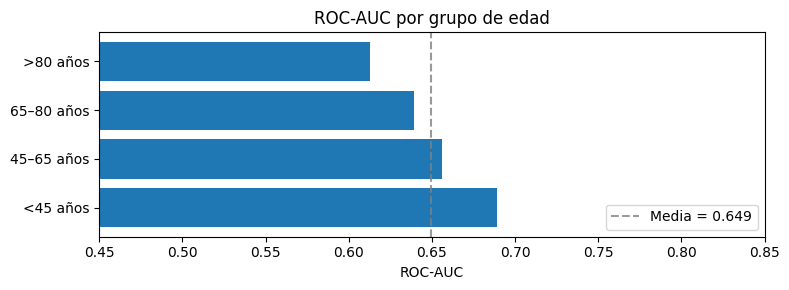

<Axes: title={'center': 'ROC-AUC por grupo de edad'}, xlabel='ROC-AUC'>

In [6]:
age_test = df["age_group"].loc[X_test.index]
age_df = metrics_by_subgroup(best_model, X_test, y_test, age_test)
print(age_df.to_string(index=False))
plot_subgroup_auc(age_df, "grupo de edad",
                  save_path="../results/subgroup_age.png")

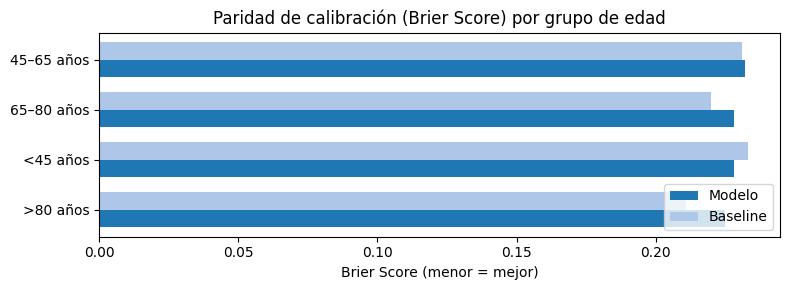

<Axes: title={'center': 'Paridad de calibración (Brier Score) por grupo de edad'}, xlabel='Brier Score (menor = mejor)'>

In [7]:
plot_subgroup_brier(age_df, "grupo de edad",
                    save_path="../results/subgroup_brier_age.png")

### 3.2 Sexo

 Subgrupo     N  Prevalencia  ROC-AUC  Brier-Score  Brier-Baseline
Masculino 30995        0.370    0.656        0.236           0.233
 Femenino 33131        0.323    0.654        0.223           0.219


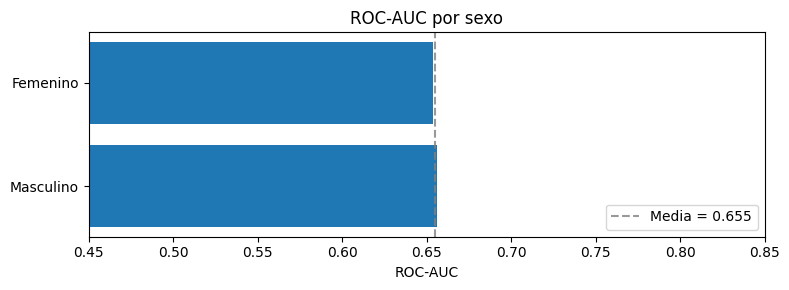

<Axes: title={'center': 'ROC-AUC por sexo'}, xlabel='ROC-AUC'>

In [8]:
gender_test = df["gender_label"].loc[X_test.index]
gender_df = metrics_by_subgroup(best_model, X_test, y_test, gender_test)
print(gender_df.to_string(index=False))
plot_subgroup_auc(gender_df, "sexo",
                  save_path="../results/subgroup_gender.png")

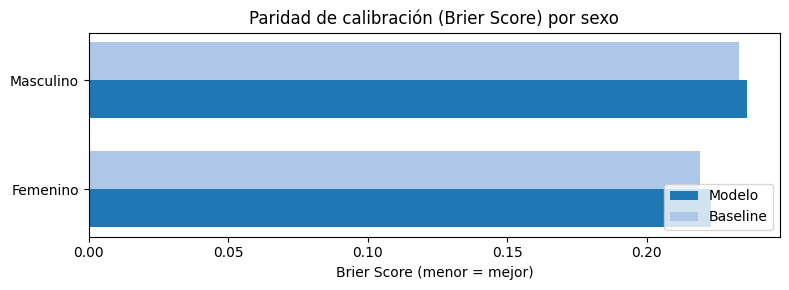

<Axes: title={'center': 'Paridad de calibración (Brier Score) por sexo'}, xlabel='Brier Score (menor = mejor)'>

In [9]:
plot_subgroup_brier(gender_df, "sexo",
                    save_path="../results/subgroup_brier_gender.png")

### 3.3 Tipo de seguro médico

   Subgrupo     N  Prevalencia  ROC-AUC  Brier-Score  Brier-Baseline
Desconocido   579        0.491    0.694        0.240           0.250
       Otro 19150        0.330    0.674        0.222           0.221
   Medicaid 14151        0.386    0.669        0.233           0.237
   Medicare 30246        0.334    0.633        0.231           0.222


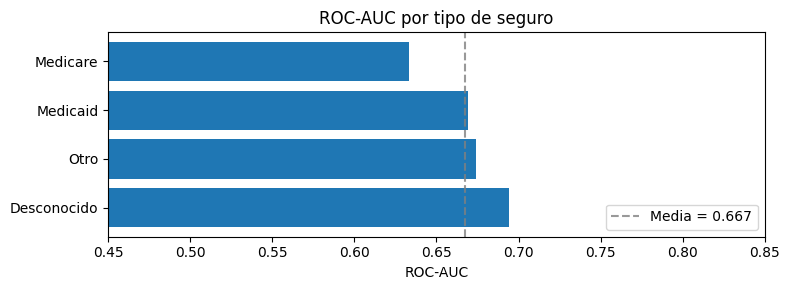

<Axes: title={'center': 'ROC-AUC por tipo de seguro'}, xlabel='ROC-AUC'>

In [10]:
insurance_test = df["insurance_group"].loc[X_test.index]
insurance_df = metrics_by_subgroup(best_model, X_test, y_test, insurance_test)
print(insurance_df.to_string(index=False))
plot_subgroup_auc(insurance_df, "tipo de seguro",
                  save_path="../results/subgroup_insurance.png")

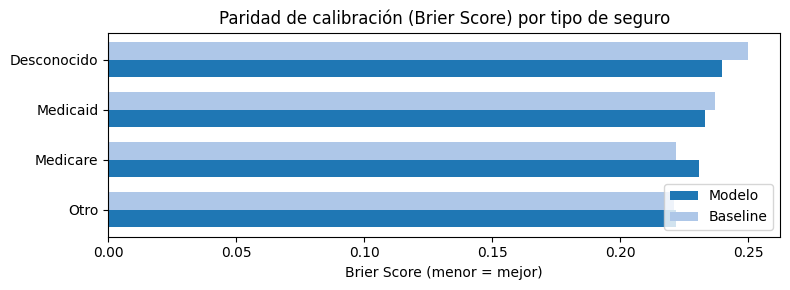

<Axes: title={'center': 'Paridad de calibración (Brier Score) por tipo de seguro'}, xlabel='Brier Score (menor = mejor)'>

In [11]:
plot_subgroup_brier(insurance_df, "tipo de seguro",
                    save_path="../results/subgroup_brier_insurance.png")

### 3.4 Diagnóstico principal

                Subgrupo     N  Prevalencia  ROC-AUC  Brier-Score  Brier-Baseline
         No especificado    56        0.393    0.774        0.202           0.239
                   Otros 10665        0.300    0.731        0.200           0.210
          Embarazo/Parto   906        0.247    0.700        0.182           0.186
              Neoplasias  4514        0.392    0.653        0.229           0.238
            Salud mental  6114        0.529    0.652        0.234           0.249
      Sist. respiratorio  3598        0.305    0.647        0.232           0.212
  Endocrinas/Metabólicas  2743        0.330    0.629        0.238           0.221
            Traumatismos  6425        0.344    0.629        0.241           0.226
  Síntomas inespecíficos  1968        0.303    0.622        0.238           0.211
             Infecciosas  2633        0.370    0.620        0.249           0.233
    Sist. genitourinario  2973        0.308    0.619        0.231           0.213
         Sist. d

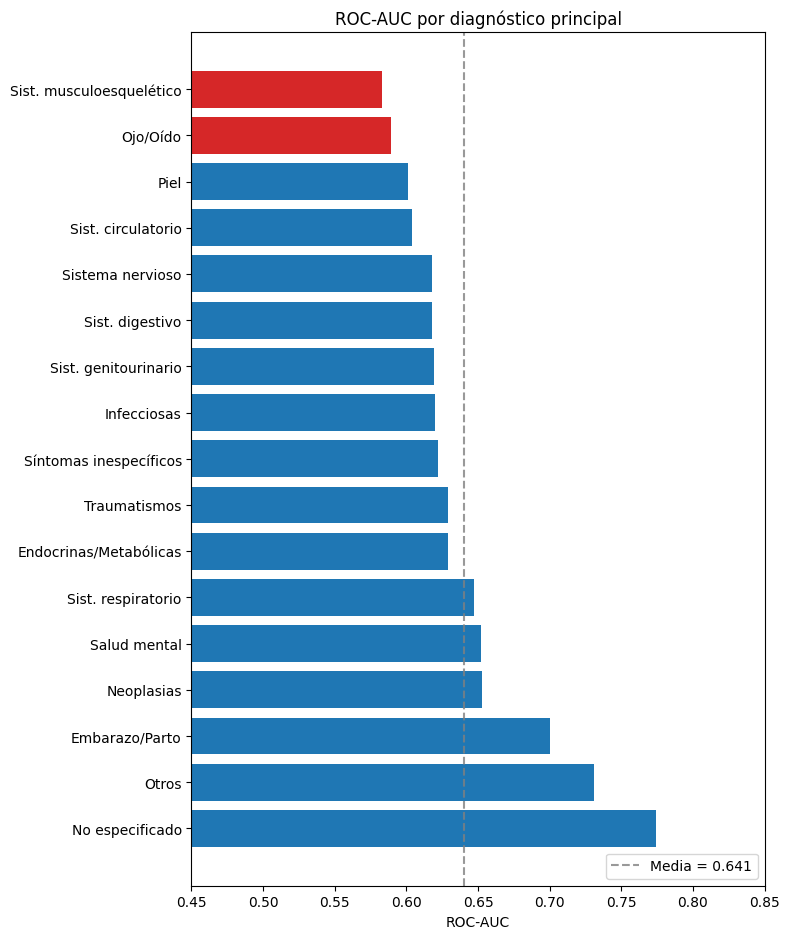

<Axes: title={'center': 'ROC-AUC por diagnóstico principal'}, xlabel='ROC-AUC'>

In [12]:
diag_test = df["diag_system"].loc[X_test.index]
diag_df = metrics_by_subgroup(best_model, X_test, y_test, diag_test)
print(diag_df.to_string(index=False))
plot_subgroup_auc(diag_df, "diagnóstico principal",
                  save_path="../results/subgroup_diagnosis.png")

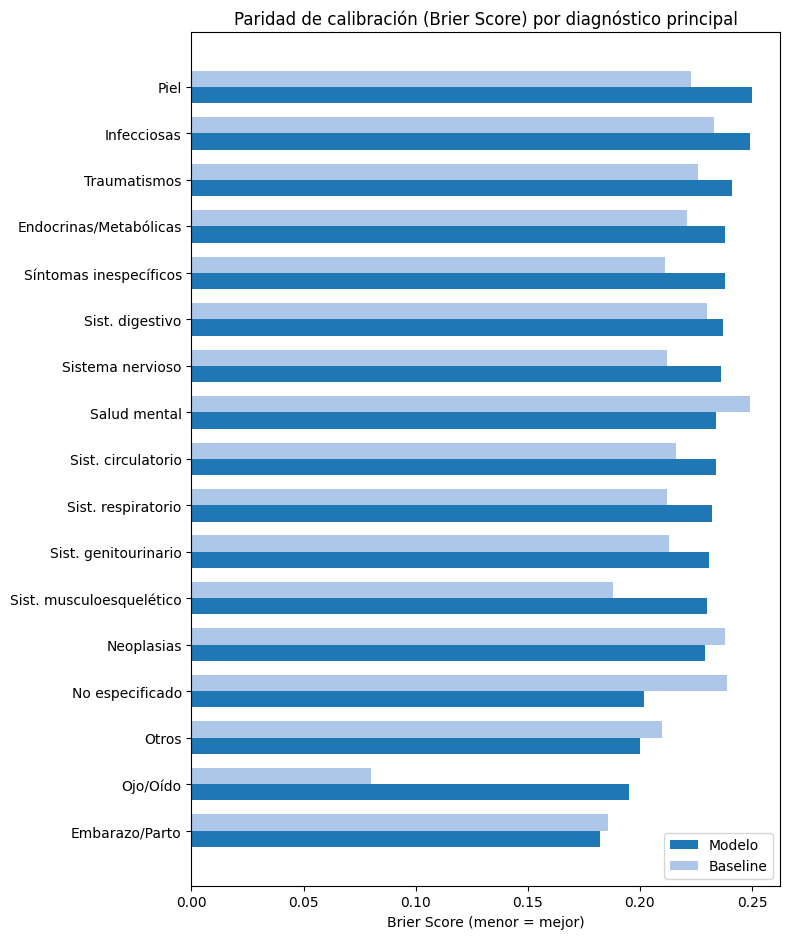

<Axes: title={'center': 'Paridad de calibración (Brier Score) por diagnóstico principal'}, xlabel='Brier Score (menor = mejor)'>

In [13]:
plot_subgroup_brier(diag_df, "diagnóstico principal",
                    save_path="../results/subgroup_brier_diagnosis.png")

## 4. Visión global

Tabla comparativa de todas las métricas por subgrupo y dimensión.

In [14]:
def add_dimension(df, label):
    df = df.copy()
    df.insert(0, "Dimensión", label)
    return df

summary = pd.concat([
    add_dimension(age_df,       "Edad"),
    add_dimension(gender_df,    "Sexo"),
    add_dimension(insurance_df, "Seguro"),
    add_dimension(diag_df,      "Diagnóstico"),
], ignore_index=True)

summary

,Dimensión,Subgrupo,N,Prevalencia,ROC-AUC,Brier-Score,Brier-Baseline
0,Edad,<45 años,14080,0.369,0.689,0.228,0.233
1,Edad,45–65 años,23410,0.362,0.656,0.232,0.231
2,Edad,65–80 años,17335,0.327,0.639,0.228,0.220
3,Edad,>80 años,9301,0.303,0.613,0.225,0.211
4,Sexo,Masculino,30995,0.370,0.656,0.236,0.233
5,Sexo,Femenino,33131,0.323,0.654,0.223,0.219
6,Seguro,Desconocido,579,0.491,0.694,0.240,0.250
7,Seguro,Otro,19150,0.330,0.674,0.222,0.221
8,Seguro,Medicaid,14151,0.386,0.669,0.233,0.237
9,Seguro,Medicare,30246,0.334,0.633,0.231,0.222


## 5. Conclusiones

En general el modelo funciona de forma bastante equitativa, aunque hay algunas diferencias que vale la pena comentar.

**Discriminación (ROC-AUC):**
- En **edad** hay un gradiente claro: el modelo va mejor en pacientes jóvenes (AUC 0.689 en menores de 45) que en mayores de 80 (AUC 0.613). Probablemente porque a mayor edad hay más heterogeneidad de comorbilidades que las variables administrativas no recogen bien.
- Por **sexo** apenas hay diferencia (0.656 vs 0.654), lo cual es una buena señal de equidad.
- Por **tipo de seguro**, Medicare tiene el AUC más bajo (0.633). El seguro actúa como proxy socioeconómico y los patrones de reingreso difieren entre grupos.
- Por **diagnóstico principal** es donde más variación hay: desde 0.731 en "Otros" hasta 0.583 en musculoesquelético. Los grupos con patologías más específicas tienen peor discriminación porque sus factores de reingreso no quedan bien reflejados en variables administrativas.

**Calibración (Brier Score):**
La calibración es más irregular. Algunos grupos como "Otros" o Embarazo/Parto calibran bien. En cambio, Traumatismos, Piel e Infecciosas superan el baseline, lo que indica que el modelo sobreestima el riesgo en esos grupos. Esto es consecuencia del ajuste de pesos para compensar el desbalanceo. En producción convendría calibrar antes de usar las probabilidades directamente.

El modelo mantiene AUC por encima de 0.60 en casi todos los subgrupos, lo que sugiere un comportamiento bastante equitativo teniendo en cuenta que solo usa variables administrativas.

> **Nota:** los subgrupos con N < 100 ("No especificado" y "Ojo/Oído") no se interpretan por falta de potencia estadística.